# 1. Interpolación en malla regular

Interpolar los datos batimétricos sobre una malla espacial regular de 5 metros, con el fin de obtener una representacion estructurada de la batimetría.

## 1.1. Entradas

- Datos batimétricos en formato XYZ (coordenadas X, Y, profundidad Z).
- Polígono del área común de análisis.

## 1.2. Salidas

- Campos batimétricos interpolados sobre la malla regular.
- Base estructurada para la generación de teselas y muestras del modelo.

## 1.3. Implementación

A continuación se presenta el fragmento principal del código utilizado para la interpolación de los datos sobre la malla:

```python
from scipy.interpolate import RBFInterpolator

# Construcción del interpolador a partir de datos dispersos
interp = RBFInterpolator(
    df[['X', 'Y']].values,
    df['Z'].values,
    smoothing=0.5,
    neighbors=50
)

# Interpolación sobre la malla (solo puntos válidos)
z_validos = interp(pts_validos)

# Reconstrucción de la malla 2D completa
z_grid = np.full(gx.shape, np.nan, dtype=float)
z_grid.ravel()[mask] = z_validos


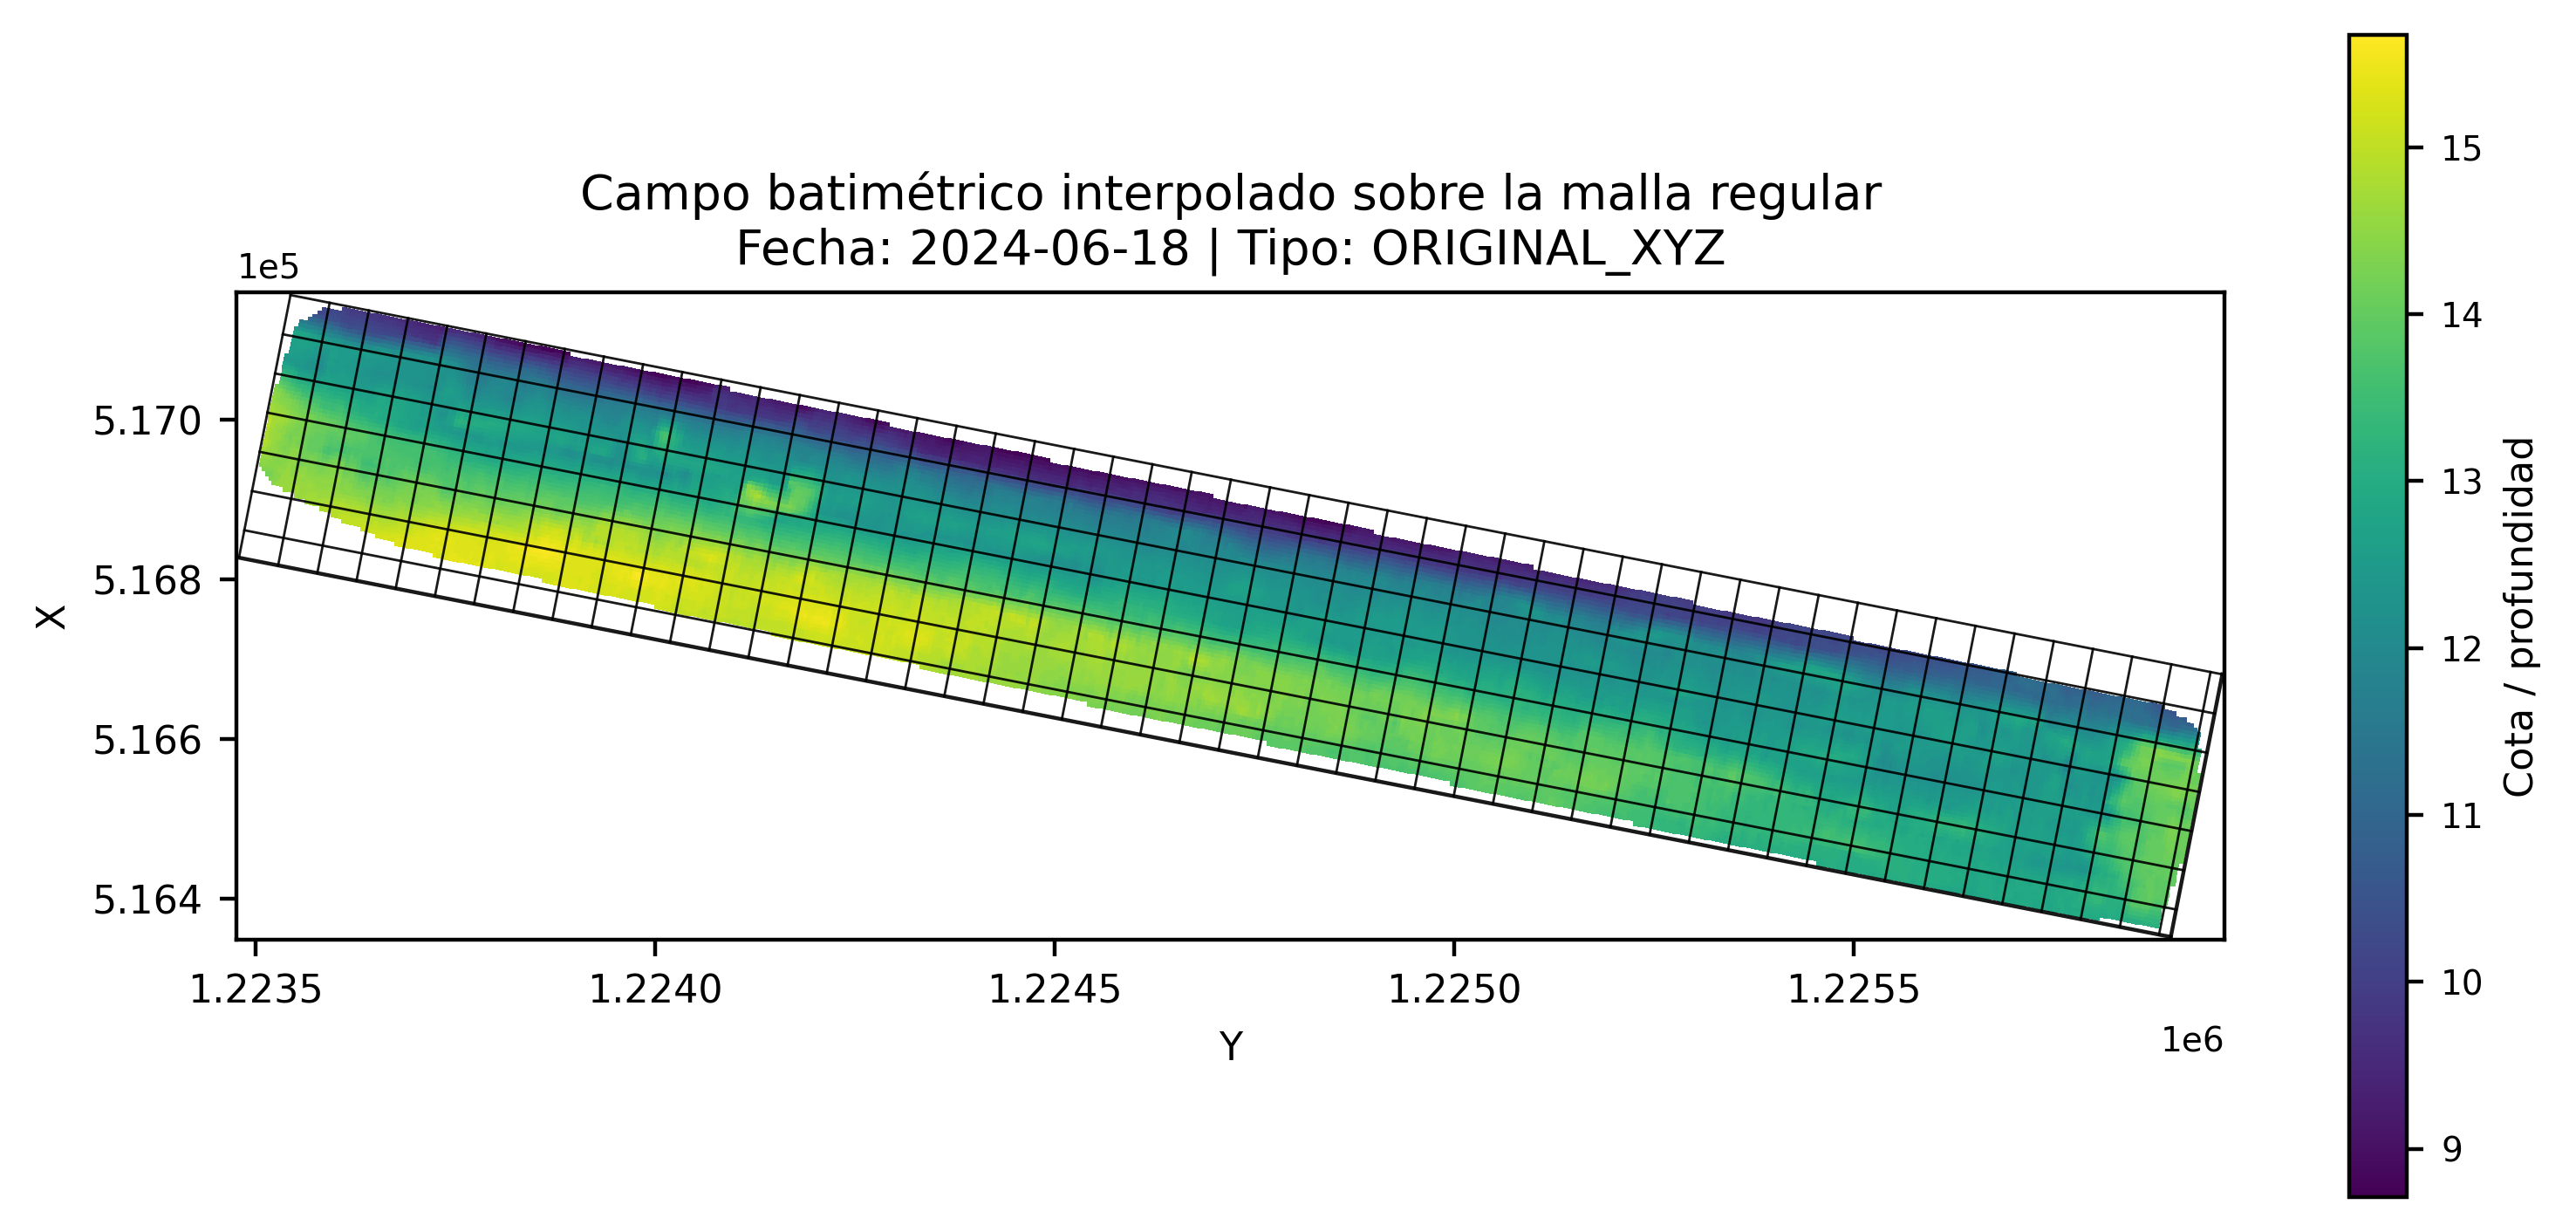

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# 1. PARÁMETROS
SECTOR = "X6By5"
GRID_STEP_PLOT = 10

plt.rcParams["figure.dpi"] = 400

ruta_grid_base = rf"C:\Users\Victus\Documents\RedesNeuronales\6_RNN_Batimetrias\ConvLSTM\X6By5\1_MallasInterpoladas_X6By5\grid_base_X6By5_5m.npz"
ruta_npz_interpolado = rf"C:\Users\Victus\Documents\RedesNeuronales\6_RNN_Batimetrias\ConvLSTM\X6By5\1_MallasInterpoladas_X6By5\batimetria_interpolada_X6By5_20240618.npz"

carpeta_salida = rf"C:\Users\Victus\Documents\RedesNeuronales\6_RNN_Batimetrias\ConvLSTM\jbook_LSMTConv\docs\images"
os.makedirs(carpeta_salida, exist_ok=True)

nombre_figura = "campo_interpolado_con_malla_base.png"

# 2. LEER NPZ DE MALLA BASE
grid_data = np.load(ruta_grid_base)

gx = grid_data["gx"]
gy = grid_data["gy"]
mask_grid = grid_data["mask_grid"]
centroide = grid_data["centroide"]
u = grid_data["u"]
v = grid_data["v"]

X_real = centroide[0] + gx * v[0] + gy * u[0]
Y_real = centroide[1] + gx * v[1] + gy * u[1]

# 3. LEER CAMPO INTERPOLADO
campo_data = np.load(ruta_npz_interpolado)
z_grid = campo_data["z_grid"]

fecha = campo_data["fecha"][0] if "fecha" in campo_data else "sin_fecha"
source_type = campo_data["source_type"][0] if "source_type" in campo_data else "NA"

# 4. GRAFICAR
fig, ax = plt.subplots(figsize=(8, 4), dpi=400)

# Intercambiar ejes para que se vea "rotada"
pcm = ax.pcolormesh(
    Y_real,
    X_real,
    z_grid,
    shading="auto"
)

nrows, ncols = z_grid.shape

# Líneas horizontales
for i in range(0, nrows, GRID_STEP_PLOT):
    ax.plot(
        Y_real[i, :],
        X_real[i, :],
        color="black",
        linewidth=0.5,
        alpha=0.9
    )

# Líneas verticales
for j in range(0, ncols, GRID_STEP_PLOT):
    ax.plot(
        Y_real[:, j],
        X_real[:, j],
        color="black",
        linewidth=0.5,
        alpha=0.9
    )

# Bordes finales
ax.plot(Y_real[-1, :], X_real[-1, :], color="black", linewidth=0.8, alpha=0.9)
ax.plot(Y_real[:, -1], X_real[:, -1], color="black", linewidth=0.8, alpha=0.9)

# Notación científica
ax.ticklabel_format(axis="both", style="sci", scilimits=(0, 0))
ax.xaxis.get_offset_text().set_size(7)
ax.yaxis.get_offset_text().set_size(7)

# Barra de color
cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.set_label("Cota / profundidad", fontsize=8)
cbar.ax.tick_params(labelsize=7)

# Formato
ax.set_title(
    f"Campo batimétrico interpolado sobre la malla regular\nFecha: {fecha} | Tipo: {source_type}",
    fontsize=10
)
ax.set_xlabel("Y", fontsize=8)
ax.set_ylabel("X", fontsize=8)
ax.tick_params(axis="both", labelsize=8)
ax.set_aspect("equal")

plt.tight_layout()
plt.show()